## To train ANN on the processed data for churn

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

In [2]:
data = pd.read_csv('../Data/processed_customer_churn.csv')

In [3]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,Credit card (automatic),Electronic check,Mailed check
0,0,0,1,0,1.0,0,0,1,0,1,...,0,0,0,1,29.85,3.396185,0,False,True,False
1,1,0,0,0,34.0,1,0,1,1,0,...,0,0,1,0,56.95,7.544068,0,False,False,True
2,1,0,0,0,2.0,1,0,1,1,1,...,0,0,0,1,53.85,4.683519,1,False,False,True
3,1,0,0,0,45.0,0,0,1,1,0,...,0,0,1,0,42.30,7.517928,0,False,False,False
4,0,0,0,0,2.0,1,0,2,0,0,...,0,0,0,1,70.70,5.021575,1,False,True,False


In [4]:
X = data.drop('Churn', axis= 1)
y = data['Churn']

In [5]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X = sc.fit_transform(X)

### traintest split

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, stratify= y, random_state= 0)

print(y_train.value_counts())
print(y_test.value_counts())

Churn
0    4139
1    1495
Name: count, dtype: int64
Churn
0    1035
1     374
Name: count, dtype: int64


## Model training

In [ ]:
import torch

class CustomANN:

    def __init__(self, input_size, hidden_sizes, output_size, learning_rate=0.01): #hidden sizes is a list

        self.lr = learning_rate
        self.weights = []
        self.biases = []
        
        layer_sizes = [input_size] + hidden_sizes + [output_size]
        
        for i in range(len(layer_sizes) - 1):
            w = torch.randn(layer_sizes[i], layer_sizes[i+1]) * np.sqrt(2.0 / layer_sizes[i])
            b = torch.zeros(layer_sizes[i+1])
            
            w.requires_grad = True
            b.requires_grad = True
            
            self.weights.append(w)
            self.biases.append(b)
        
        for i, (w, b) in enumerate(zip(self.weights, self.biases)):
            print(f"Layer {i+1}: {w.shape[0]} -> {w.shape[1]}")
    
    def relu(self, x):
        """ReLU activation function"""
        return torch.maximum(torch.tensor(0.0), x)
    
    def sigmoid(self, x):
        """Sigmoid activation function"""
        return 1 / (1 + torch.exp(-x))
    
    def forward(self, X):
        """Forward propagation through the network"""
        self.activations = [X]
        
        # hidden layers
        for i in range(len(self.weights) - 1):
            z = torch.matmul(self.activations[-1], self.weights[i]) + self.biases[i]
            a = self.relu(z)
            self.activations.append(a)
        
        # out layer
        z_out = torch.matmul(self.activations[-1], self.weights[-1]) + self.biases[-1]
        y_pred = self.sigmoid(z_out)
        self.activations.append(y_pred)
        
        return y_pred
    
    def binary_cross_entropy(self, y_pred, y_true):
        """Binary Cross-Entropy Loss function"""
        epsilon = 1e-7
        y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)
        loss = -torch.mean(y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred))
        return loss
    
    def train_model(self, X_train, y_train, X_val, y_val, epochs=100):
        # Convert to PyTorch tensors
        X_train_tensor = torch.FloatTensor(X_train)
        y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
        X_val_tensor = torch.FloatTensor(X_val)
        y_val_tensor = torch.FloatTensor(y_val).reshape(-1, 1)
        
        train_losses = []
        val_losses = []
        
        print(f"Epochs: {epochs}, Learning Rate: {self.lr}")
        
        n_samples = len(X_train_tensor)
        
        for epoch in range(epochs):
            epoch_loss = 0
            indices = torch.randperm(n_samples)
            
            # Stochastic Gradient Descent (update after each sample)
            for i in indices:
                sample_X = X_train_tensor[i:i+1]
                sample_y = y_train_tensor[i:i+1]
                
                # Forward pass
                y_pred = self.forward(sample_X)
                loss = self.binary_cross_entropy(y_pred, sample_y)
                
                # Backward pass
                loss.backward()
                
                # Update weights
                with torch.no_grad():
                    for w, b in zip(self.weights, self.biases):
                        if w.grad is not None:
                            w -= self.lr * w.grad
                            b -= self.lr * b.grad
                            w.grad.zero_()
                            b.grad.zero_()
                
                epoch_loss += loss.item()
            
            # Calculate average training loss
            avg_train_loss = epoch_loss / n_samples
            train_losses.append(avg_train_loss)
            
            # Validation loss
            with torch.no_grad():
                val_pred = self.forward(X_val_tensor)
                val_loss = self.binary_cross_entropy(val_pred, y_val_tensor)
                val_losses.append(val_loss.item())
            
            if (epoch + 1) % 10 == 0:
                print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss.item():.4f}")
        
        return train_losses, val_losses
    
    def predict(self, X):
        """Make binary predictions"""
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X)
            y_pred = self.forward(X_tensor)
            return (y_pred.numpy() > 0.5).astype(int)
    
    def predict_proba(self, X):
        """Get prediction probabilities"""
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X)
            y_pred = self.forward(X_tensor)
            return y_pred.numpy()

In [8]:
# Initialize and train the model
input_size = X_train.shape[1]

model = CustomANN(
    input_size=input_size,
    hidden_sizes=[14, 8],  # Two hidden layers
    output_size=1,
    learning_rate=0.01
)

# Train the model
train_losses, val_losses = model.train_model(
    X_train, y_train.values,
    X_test, y_test.values,
    epochs=100
)

Layer 1: 21 → 14
Layer 2: 14 → 8
Layer 3: 8 → 1
Epochs: 100, Learning Rate: 0.01
Epoch [10/100] - Train Loss: 0.4020, Val Loss: 0.4173
Epoch [20/100] - Train Loss: 0.3966, Val Loss: 0.4270
Epoch [30/100] - Train Loss: 0.3888, Val Loss: 0.4395
Epoch [40/100] - Train Loss: 0.3812, Val Loss: 0.4510
Epoch [50/100] - Train Loss: 0.3775, Val Loss: 0.4599
Epoch [60/100] - Train Loss: 0.3706, Val Loss: 0.4717
Epoch [70/100] - Train Loss: 0.3680, Val Loss: 0.4844
Epoch [80/100] - Train Loss: 0.3624, Val Loss: 0.5043
Epoch [90/100] - Train Loss: 0.3623, Val Loss: 0.4832
Epoch [100/100] - Train Loss: 0.3587, Val Loss: 0.5329


## Model Evaluation

In [9]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                              f1_score, roc_auc_score, confusion_matrix, 
                              classification_report)

# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

# Calculate metrics
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=== Model Performance ===")
print(f"Train Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Precision:      {precision:.4f}")
print(f"Recall:         {recall:.4f}")
print(f"F1-Score:       {f1:.4f}")
print(f"ROC-AUC:        {roc_auc:.4f}")

print("\n=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred_test)
print(cm)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_test, target_names=['No Churn', 'Churn']))

=== Model Performance ===
Train Accuracy: 0.8106 (81.06%)
Test Accuracy:  0.7722 (77.22%)
Precision:      0.5674
Recall:         0.5963
F1-Score:       0.5815
ROC-AUC:        0.8002

=== Confusion Matrix ===
[[865 170]
 [151 223]]

=== Classification Report ===
              precision    recall  f1-score   support

    No Churn       0.85      0.84      0.84      1035
       Churn       0.57      0.60      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409



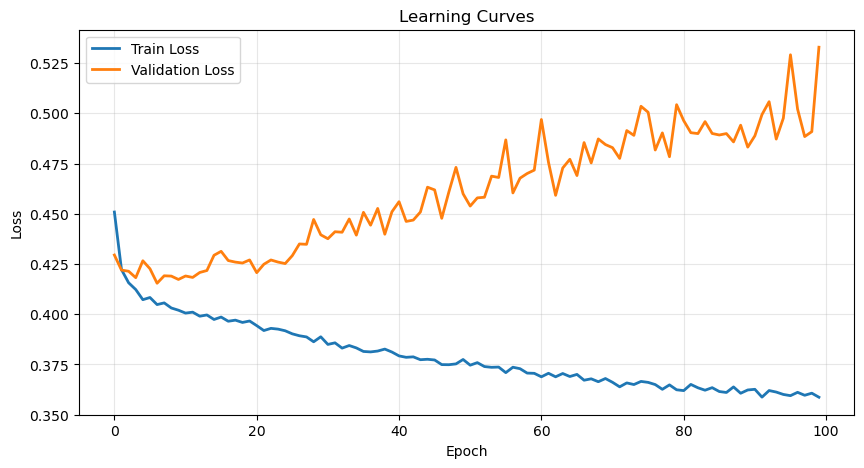

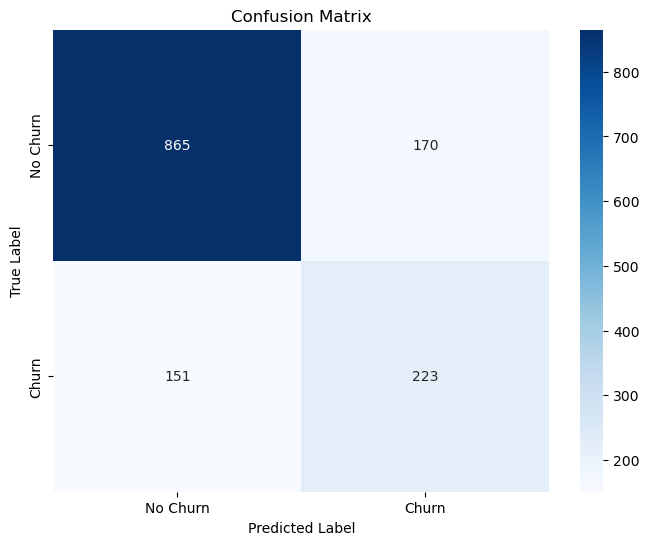

In [10]:
# Plot learning curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## SHAP Explainability

- Pls do not change the number of samples, it has a very high time of computation

In [ ]:
import shap

# Create a wrapper function for SHAP compatibility
def model_predict(X):
    """Wrapper function to make model compatible with SHAP"""
    return model.predict_proba(X).flatten()


background = shap.sample(X_train, 100) #DO NOT MAKE THIS LARGE BECAUSE IT WILL TAKE TOO MUCH TIME
explainer = shap.KernelExplainer(model_predict, background)


# Calculate SHAP values for test set (using a sample for efficiency)
X_test_sample = X_test[:100]
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values calculated successfully!")
print(f"Shape of SHAP values: {shap_values.shape}")

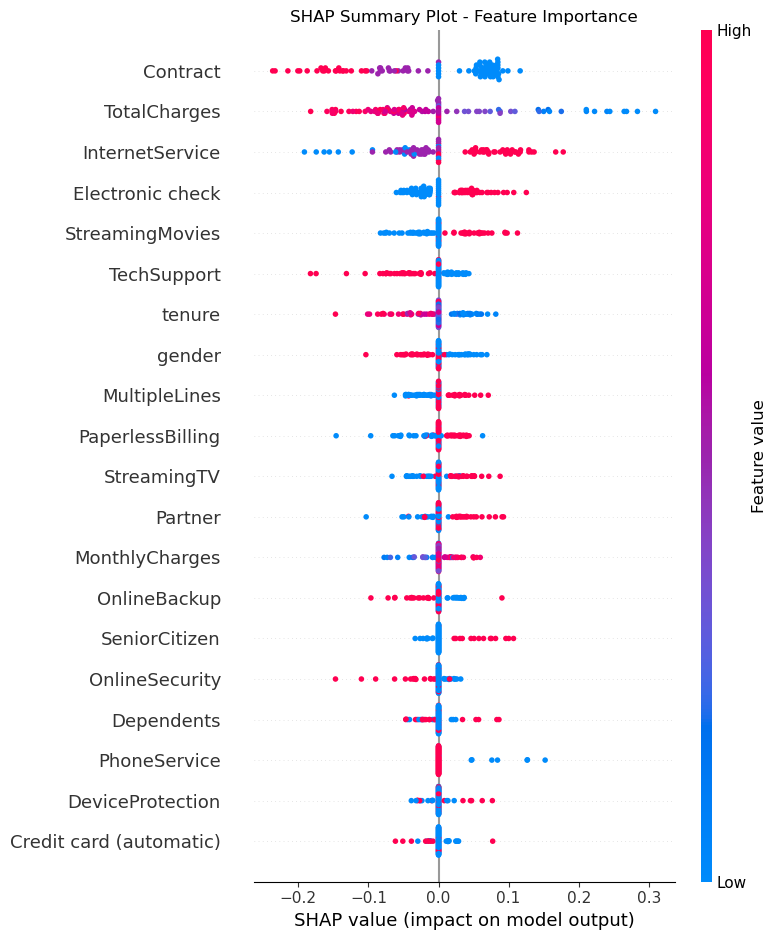

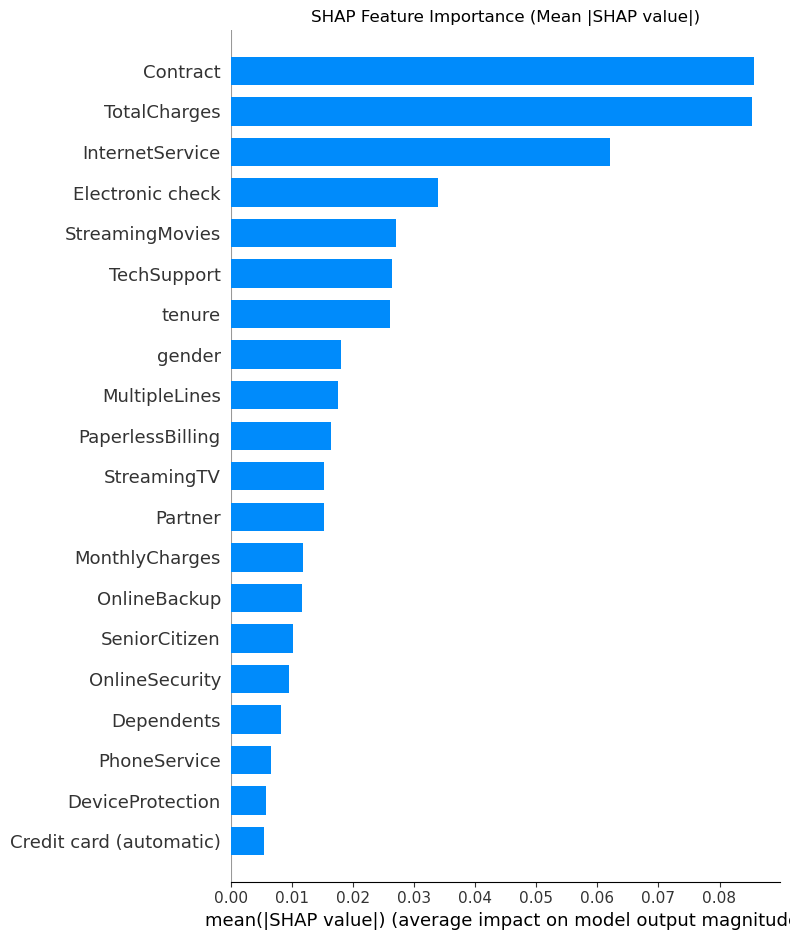

In [12]:
# Get feature names from the original data
feature_names = data.drop('Churn', axis=1).columns.tolist()

# 1. Summary plot - shows feature importance
shap.summary_plot(shap_values, X_test_sample, feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot - Feature Importance')
plt.tight_layout()
plt.show()

# 2. Bar plot - mean absolute SHAP values
shap.summary_plot(shap_values, X_test_sample, feature_names=feature_names, 
                  plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Mean |SHAP value|)')
plt.tight_layout()
plt.show()

In [13]:
# 3. Force plot for individual predictions
# Explain a specific prediction (e.g., first test sample)
sample_idx = 1

shap.initjs()
shap.force_plot(
    explainer.expected_value, 
    shap_values[sample_idx], 
    X_test_sample[sample_idx],
    feature_names=feature_names
)

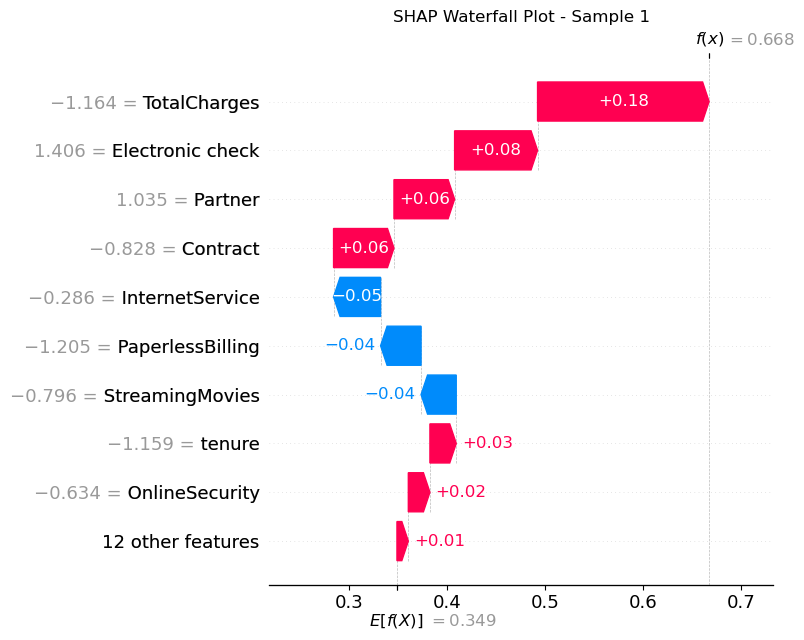

In [14]:
# 4. Waterfall plot for individual prediction
shap.plots.waterfall(shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test_sample[sample_idx],
    feature_names=feature_names
), show=False)
plt.title(f'SHAP Waterfall Plot - Sample {sample_idx}')
plt.tight_layout()
plt.show()

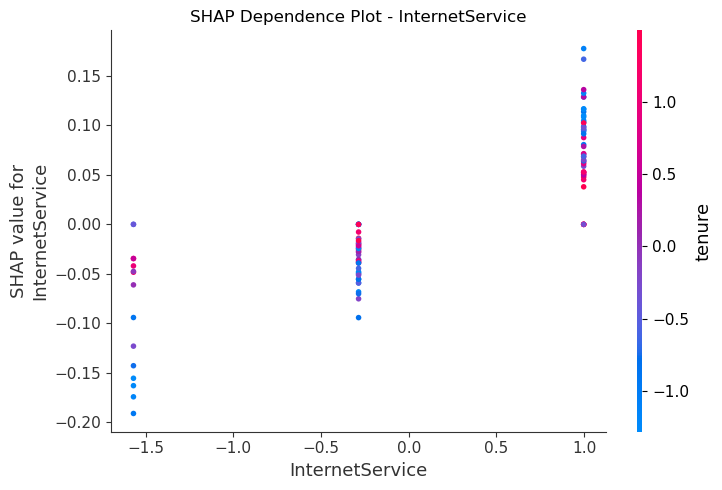

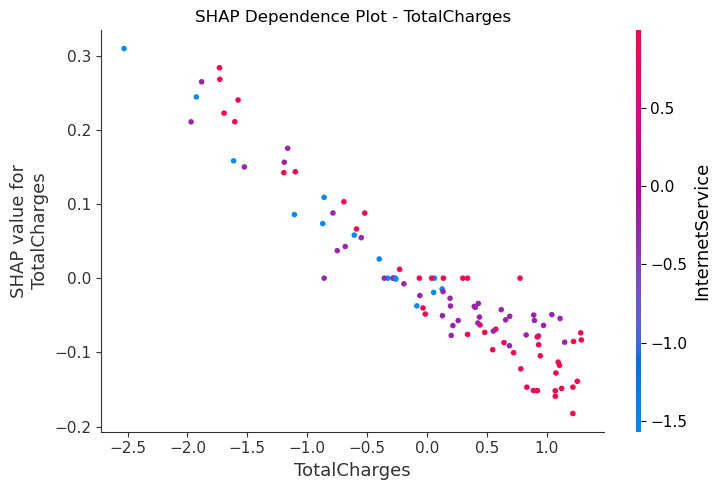

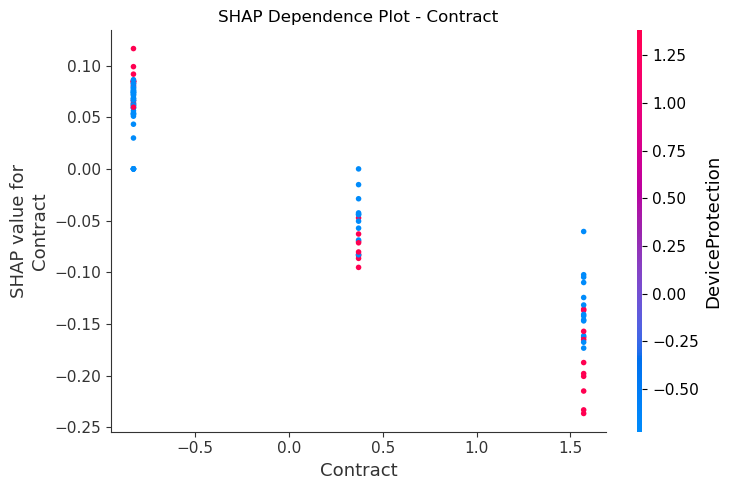

In [15]:
# 5. Dependence plot - shows interaction between features
# Choose top features to analyze
top_features = np.argsort(np.abs(shap_values).mean(0))[-3:]

for feature_idx in top_features:
    shap.dependence_plot(
        feature_idx,
        shap_values,
        X_test_sample,
        feature_names=feature_names,
        show=False
    )
    plt.title(f'SHAP Dependence Plot - {feature_names[feature_idx]}')
    plt.tight_layout()
    plt.show()